Test whether emcee chains are converged & whether the initial conditions are reasonable

In [25]:
from escripts import eMCMC
from escripts import eplots
from escripts import edata
import importlib
import emcee
import pandas as pd
from matplotlib.gridspec import GridSpec
import math
from matplotlib.ticker import MaxNLocator
import h5py

In [58]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [59]:
params = eMCMC.build_param_data({})

In [60]:
my_UVLF = eMCMC.UVLF(sorted_data, params, backend_filename = '/Users/eb35267/Desktop/code/home/data/full_chain_spread_prior.h5')

# Testing convergence

In [505]:
my_UVLF.run_MCMC(Nsteps = 205000)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 205000/205000 [6:15:26<00:00,  9.10it/s]


In [528]:
samples = my_UVLF.sampler.get_chain(discard=1900)

In [529]:
times = emcee.autocorr.integrated_time(samples, has_walkers=True)

In [530]:
times

array([ 532.38555278,  620.19242706, 1869.11975213, 1826.86408171,
        586.42360366,  431.26889157,  432.64953924,  428.72810393,
        511.09796649,  623.26494384,  410.99514167])

In [531]:
flattened_samples, _, _ = my_UVLF.get_fit(discard = 1900)

In [532]:
np.savetxt('/Users/eb35267/Desktop/code/home/data/samples_long_chain.txt', flattened_samples)

In [533]:
n_samples = len(flattened_samples)/times

In [534]:
all_data = np.hstack((np.round(times,0).reshape(-1,1), np.round(n_samples,0).reshape(-1,1)))

In [535]:
df = pd.DataFrame(data = all_data, columns = ['Autocorrelation time', '# of independent samples'], 
             index = ['alpha', 'dalphadz', 'beta', 'dbetadz', 'logMc', 'dlogMcdz', 'loge',
       'dlogedz', 'sig', 'dsigdz', 'dsigdlogM'], dtype = int, )

In [536]:
df

,Autocorrelation time,# of independent samples
alpha,532,8397
dalphadz,620,7208
beta,1869,2392
dbetadz,1827,2447
logMc,586,7623
dlogMcdz,431,10366
loge,433,10333
dlogedz,429,10427
sig,511,8747
dsigdz,623,7173


In [546]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

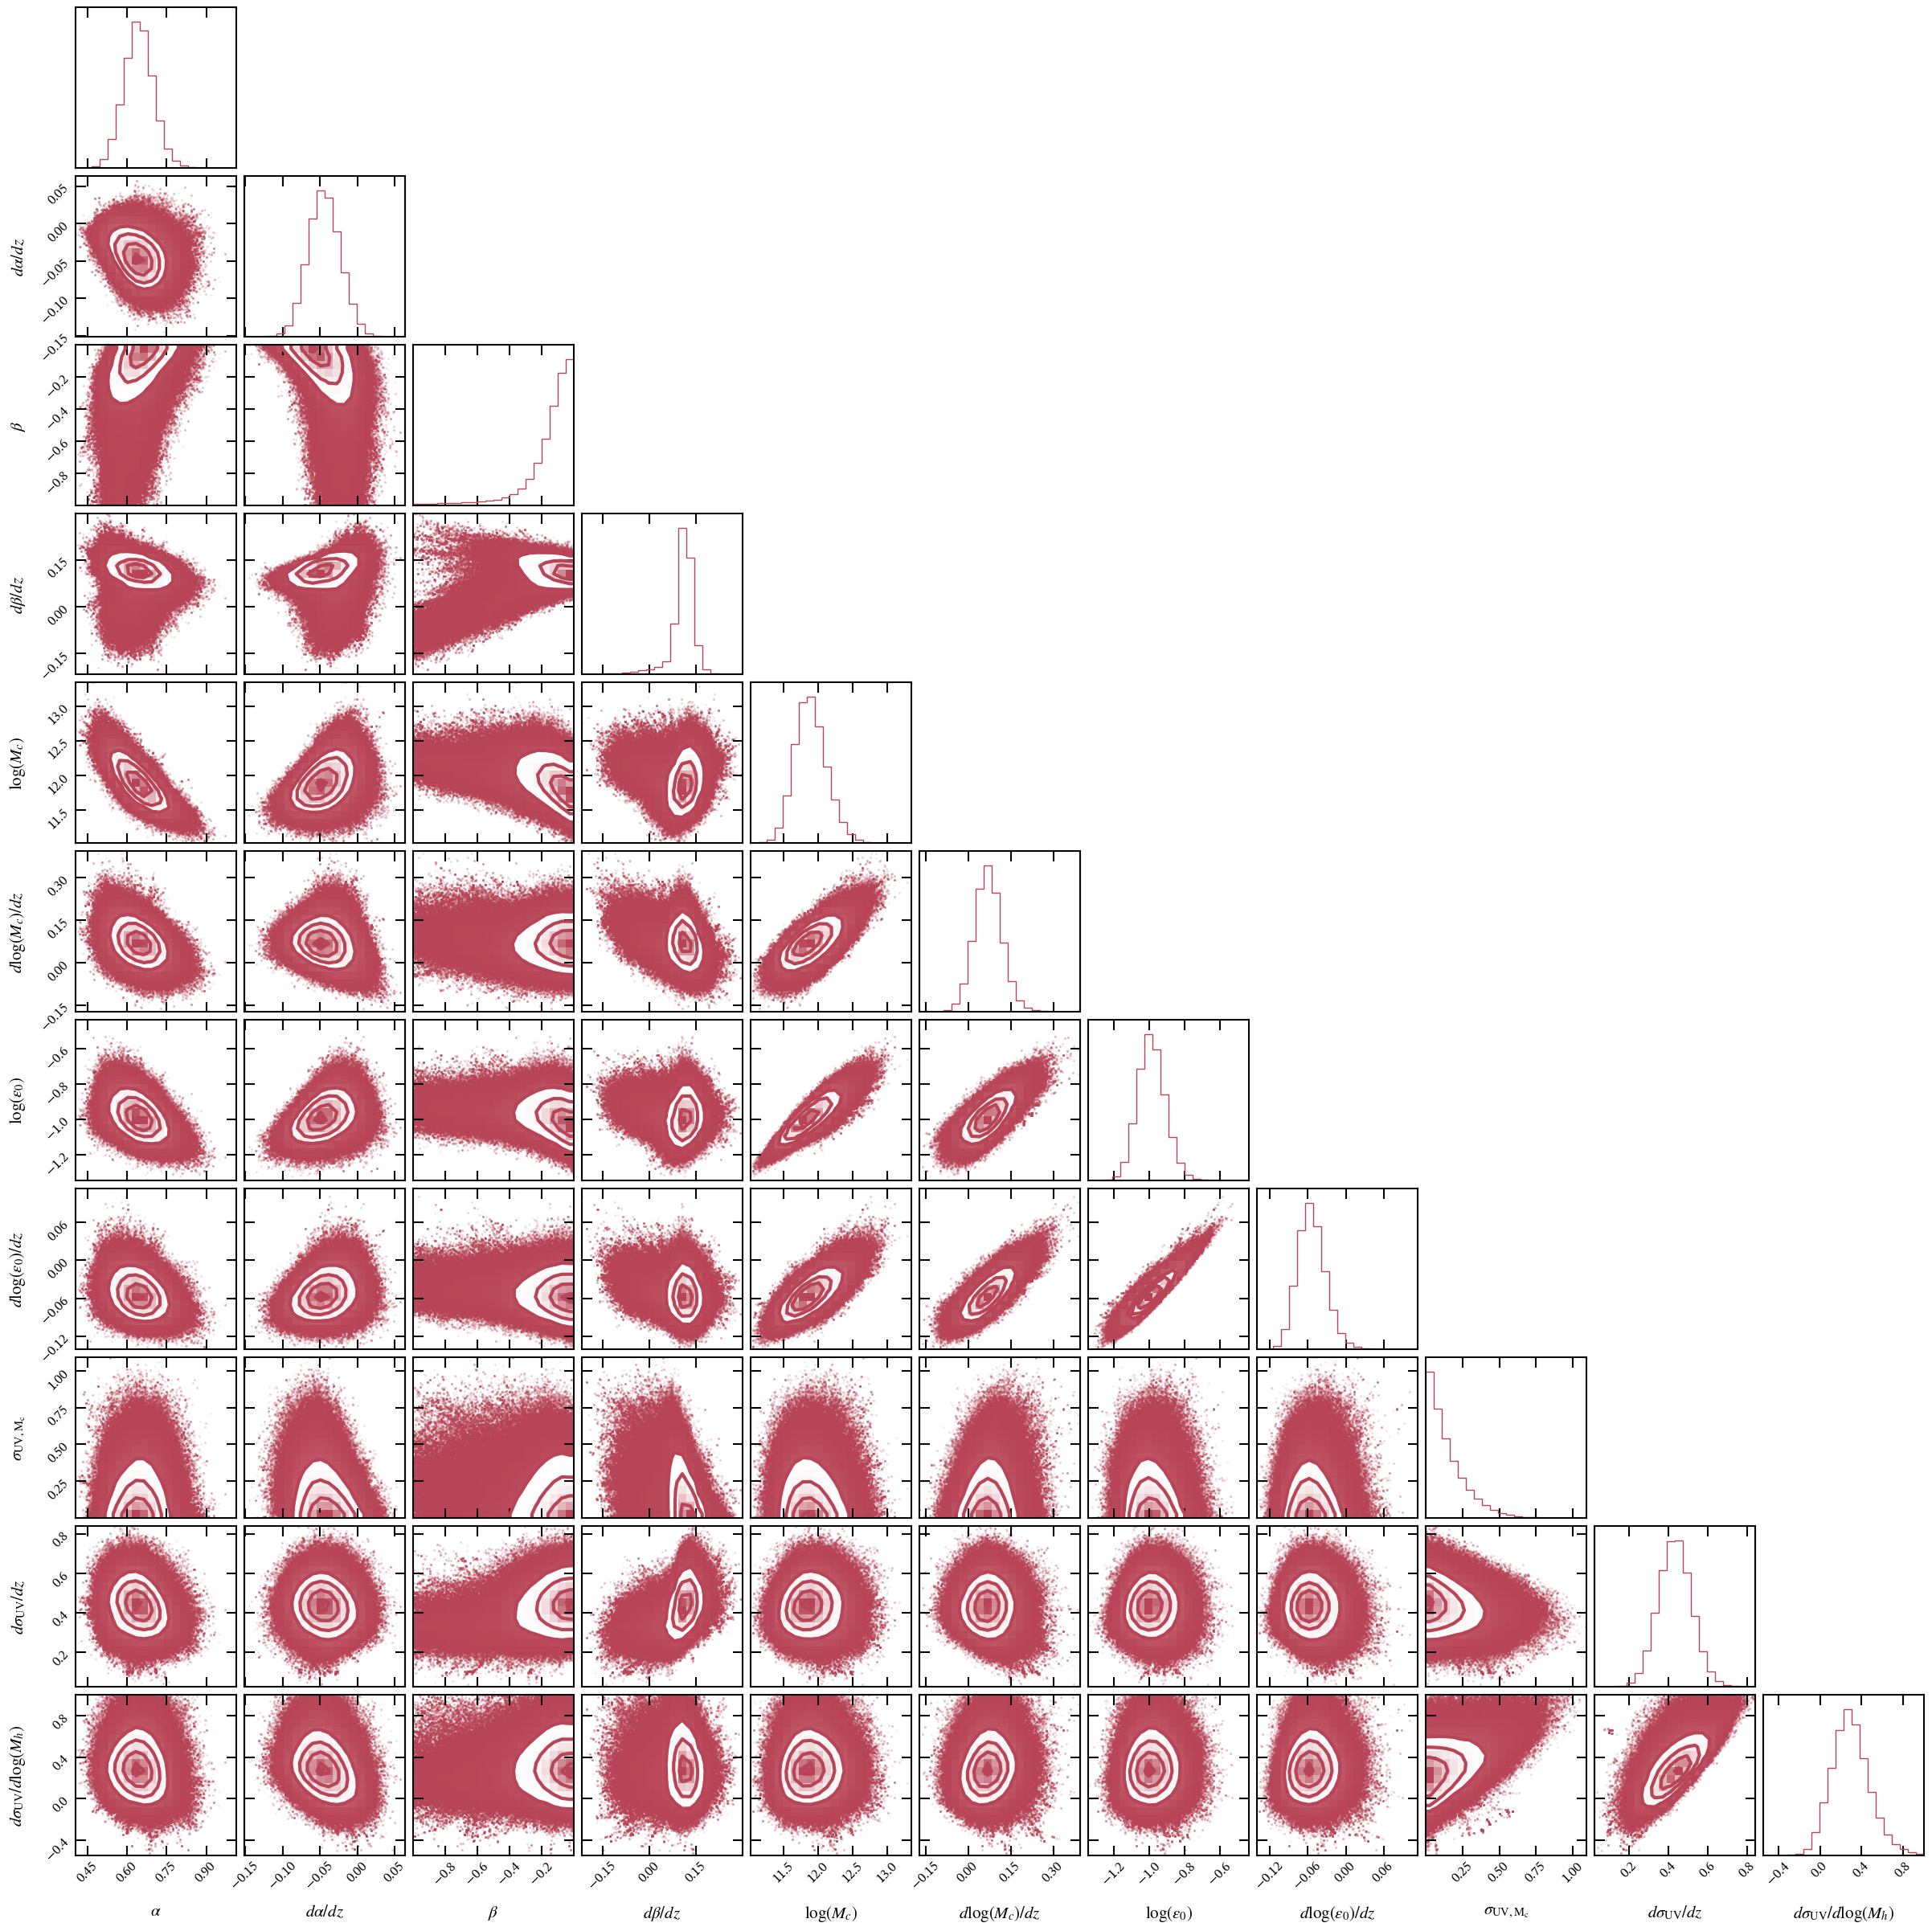

In [552]:
corner = eplots.make_corner(my_UVLF, burn_in = 8000)

In [557]:
#corner.savefig('/Users/eb35267/Desktop/code/figures/corner_broader_prior_longer_chain.png', bbox_inches = 'tight')

In [549]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

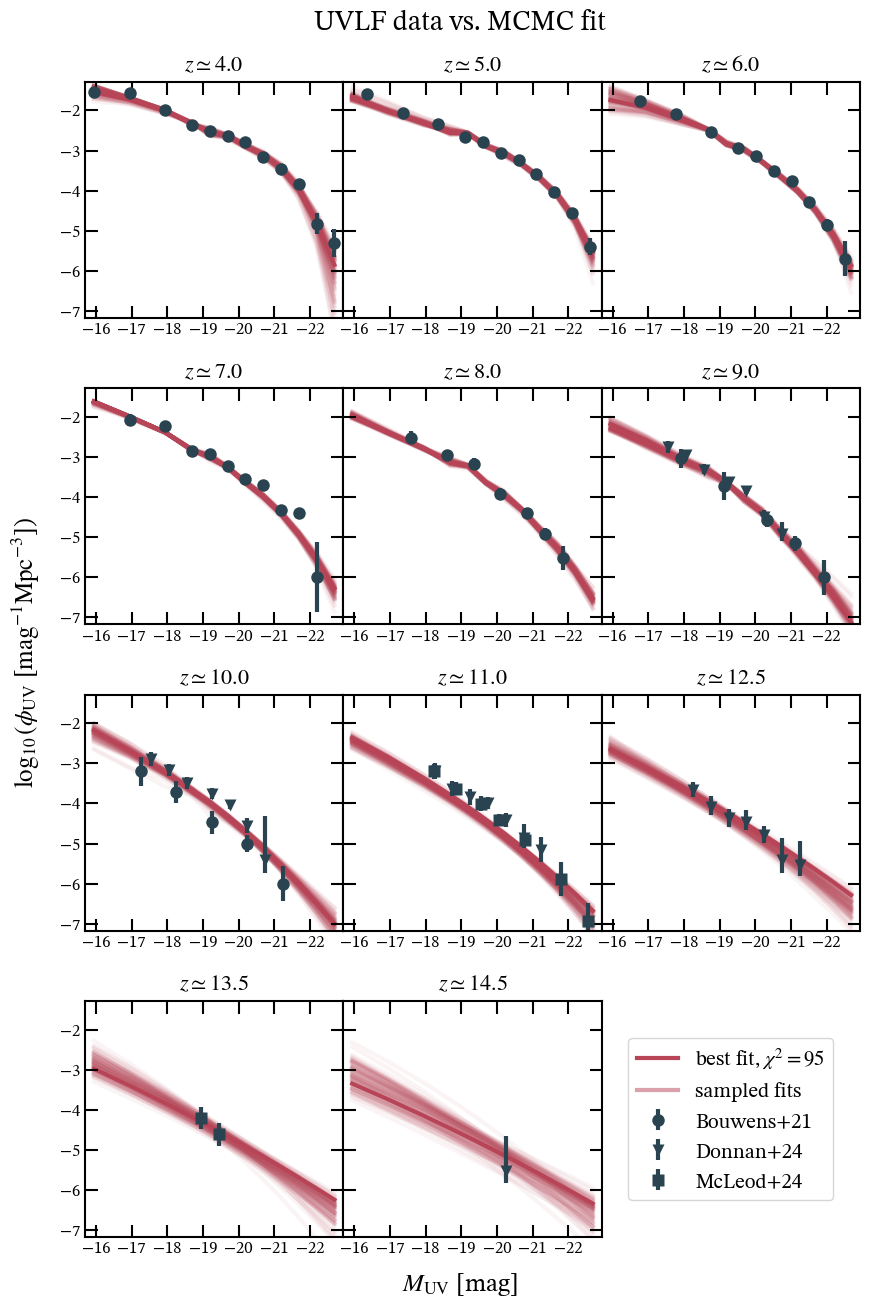

In [553]:
evolv = eplots.evolving_UVLF_fit(my_UVLF, burn_in = 8000)

In [556]:
#evolv.savefig('/Users/eb35267/Desktop/code/figures/evolving_fit_broader_prior.png', bbox_inches = 'tight')

In [554]:
samples, bf, labels = my_UVLF.get_fit(discard = 8000)

In [555]:
eMCMC.make_table([bf], [labels], ['best fit'])

,best fit
$\alpha$,0.64
$d\alpha/dz$,-0.06
$\beta$,-0.01
$d\beta/dz$,0.12
$\log(M_c)$,11.85
$d\log(M_c)/dz$,0.08
$\log(\epsilon_0)$,-0.99
$d\log(\epsilon_0)/dz$,-0.05
"$\sigma_{\rm{UV}, M_c}$",0.01
$d\sigma_{\rm{UV}}/dz$,0.50


# Testing ICs

In [ ]:
my_UVLF.run_MCMC(Nsteps = 100000)

  1%|██                                                                                                                                     | 1490/100000 [02:00<2:16:19, 12.04it/s]

In [15]:
walkers = my_UVLF.sampler.get_chain(discard = 0)

In [16]:
# true_vals = [0.64, -0.06, -0.01, 0.12, 11.85, 0.08, -0.99, -0.05, 0.01, 0.5, 0.27]
# secondary_fit = [0.75, -0.04, -0.5, -0.05, 12.25, 0.25, -0.9, 0.11, 0, -0.15, -0.4]

In [17]:
def plot_walkers(walkers, thin, true_vals, secondary_fit):
    steps = np.arange(0, len(walkers[:,0][:,0]), thin)
    walkers = walkers[0::thin]
    nplots = walkers.shape[-1]
    fig = plt.figure()
    fig.set_size_inches(10, (nplots+1))
    plt.subplots_adjust(wspace = 0.4, hspace = 0.2)
    gs = GridSpec(math.ceil((nplots+1)/3), 3, figure=fig)
    
    for i in range(nplots):
        ax = fig.add_subplot(gs[math.floor(i/3), i%3])
        for j in range(len(walkers[i])):
            ax.plot(steps, walkers[:,j][:,i], color = eplots.red, ls = '-', alpha = 0.3)
        ax.axhline(my_UVLF.param_data['lower'].iloc[i], color = eplots.yellow, label = 'upper/lower')
        ax.axhline(my_UVLF.param_data['upper'].iloc[i], color = eplots.yellow)
        ax.axhline(true_vals[i], color = eplots.turquoise, ls = '--', label = 'best fit')
        ax.axhline(secondary_fit[i], color = eplots.navy, ls = 'dotted', label = 'estimated secondary fit')
        ax.set_ylabel(fr'{my_UVLF.param_data['label'].iloc[i]}', labelpad = -0.6)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    
    ax.plot(0,0, color = eplots.red, ls = '-', alpha = 0.6, label = f'walkers, every {thin} steps') # get label
    fig_ax = fig.add_subplot(gs[math.floor((i+1)/3), (i+1)%3])
    fig_ax.axis("off")  
    handles, labels = ax.get_legend_handles_labels() # Grab handles/labels from the real axes
    fig_ax.legend(handles, labels, loc='center')
    fig.supxlabel('step number', y = 0.05)
    
    return fig

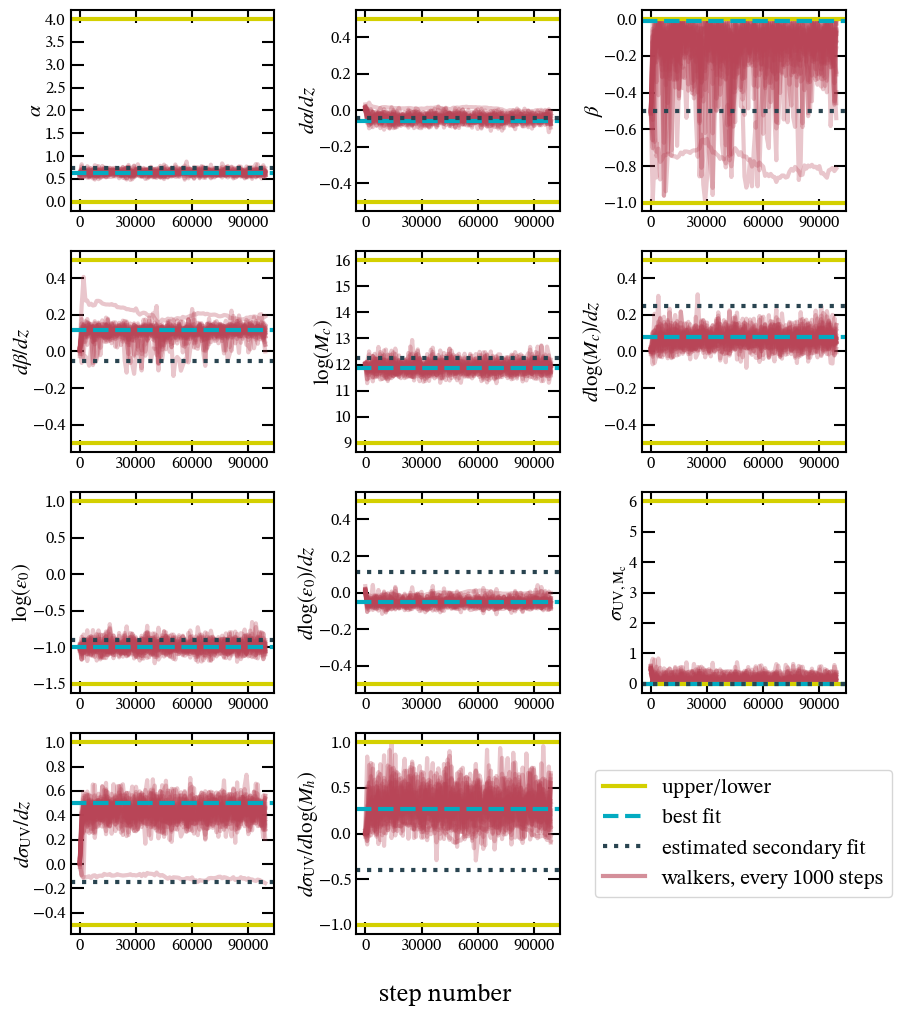

In [18]:
fig = plot_walkers(walkers, 1000, true_vals, secondary_fit)

In [21]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/thinned_chains.png', bbox_inches = 'tight')

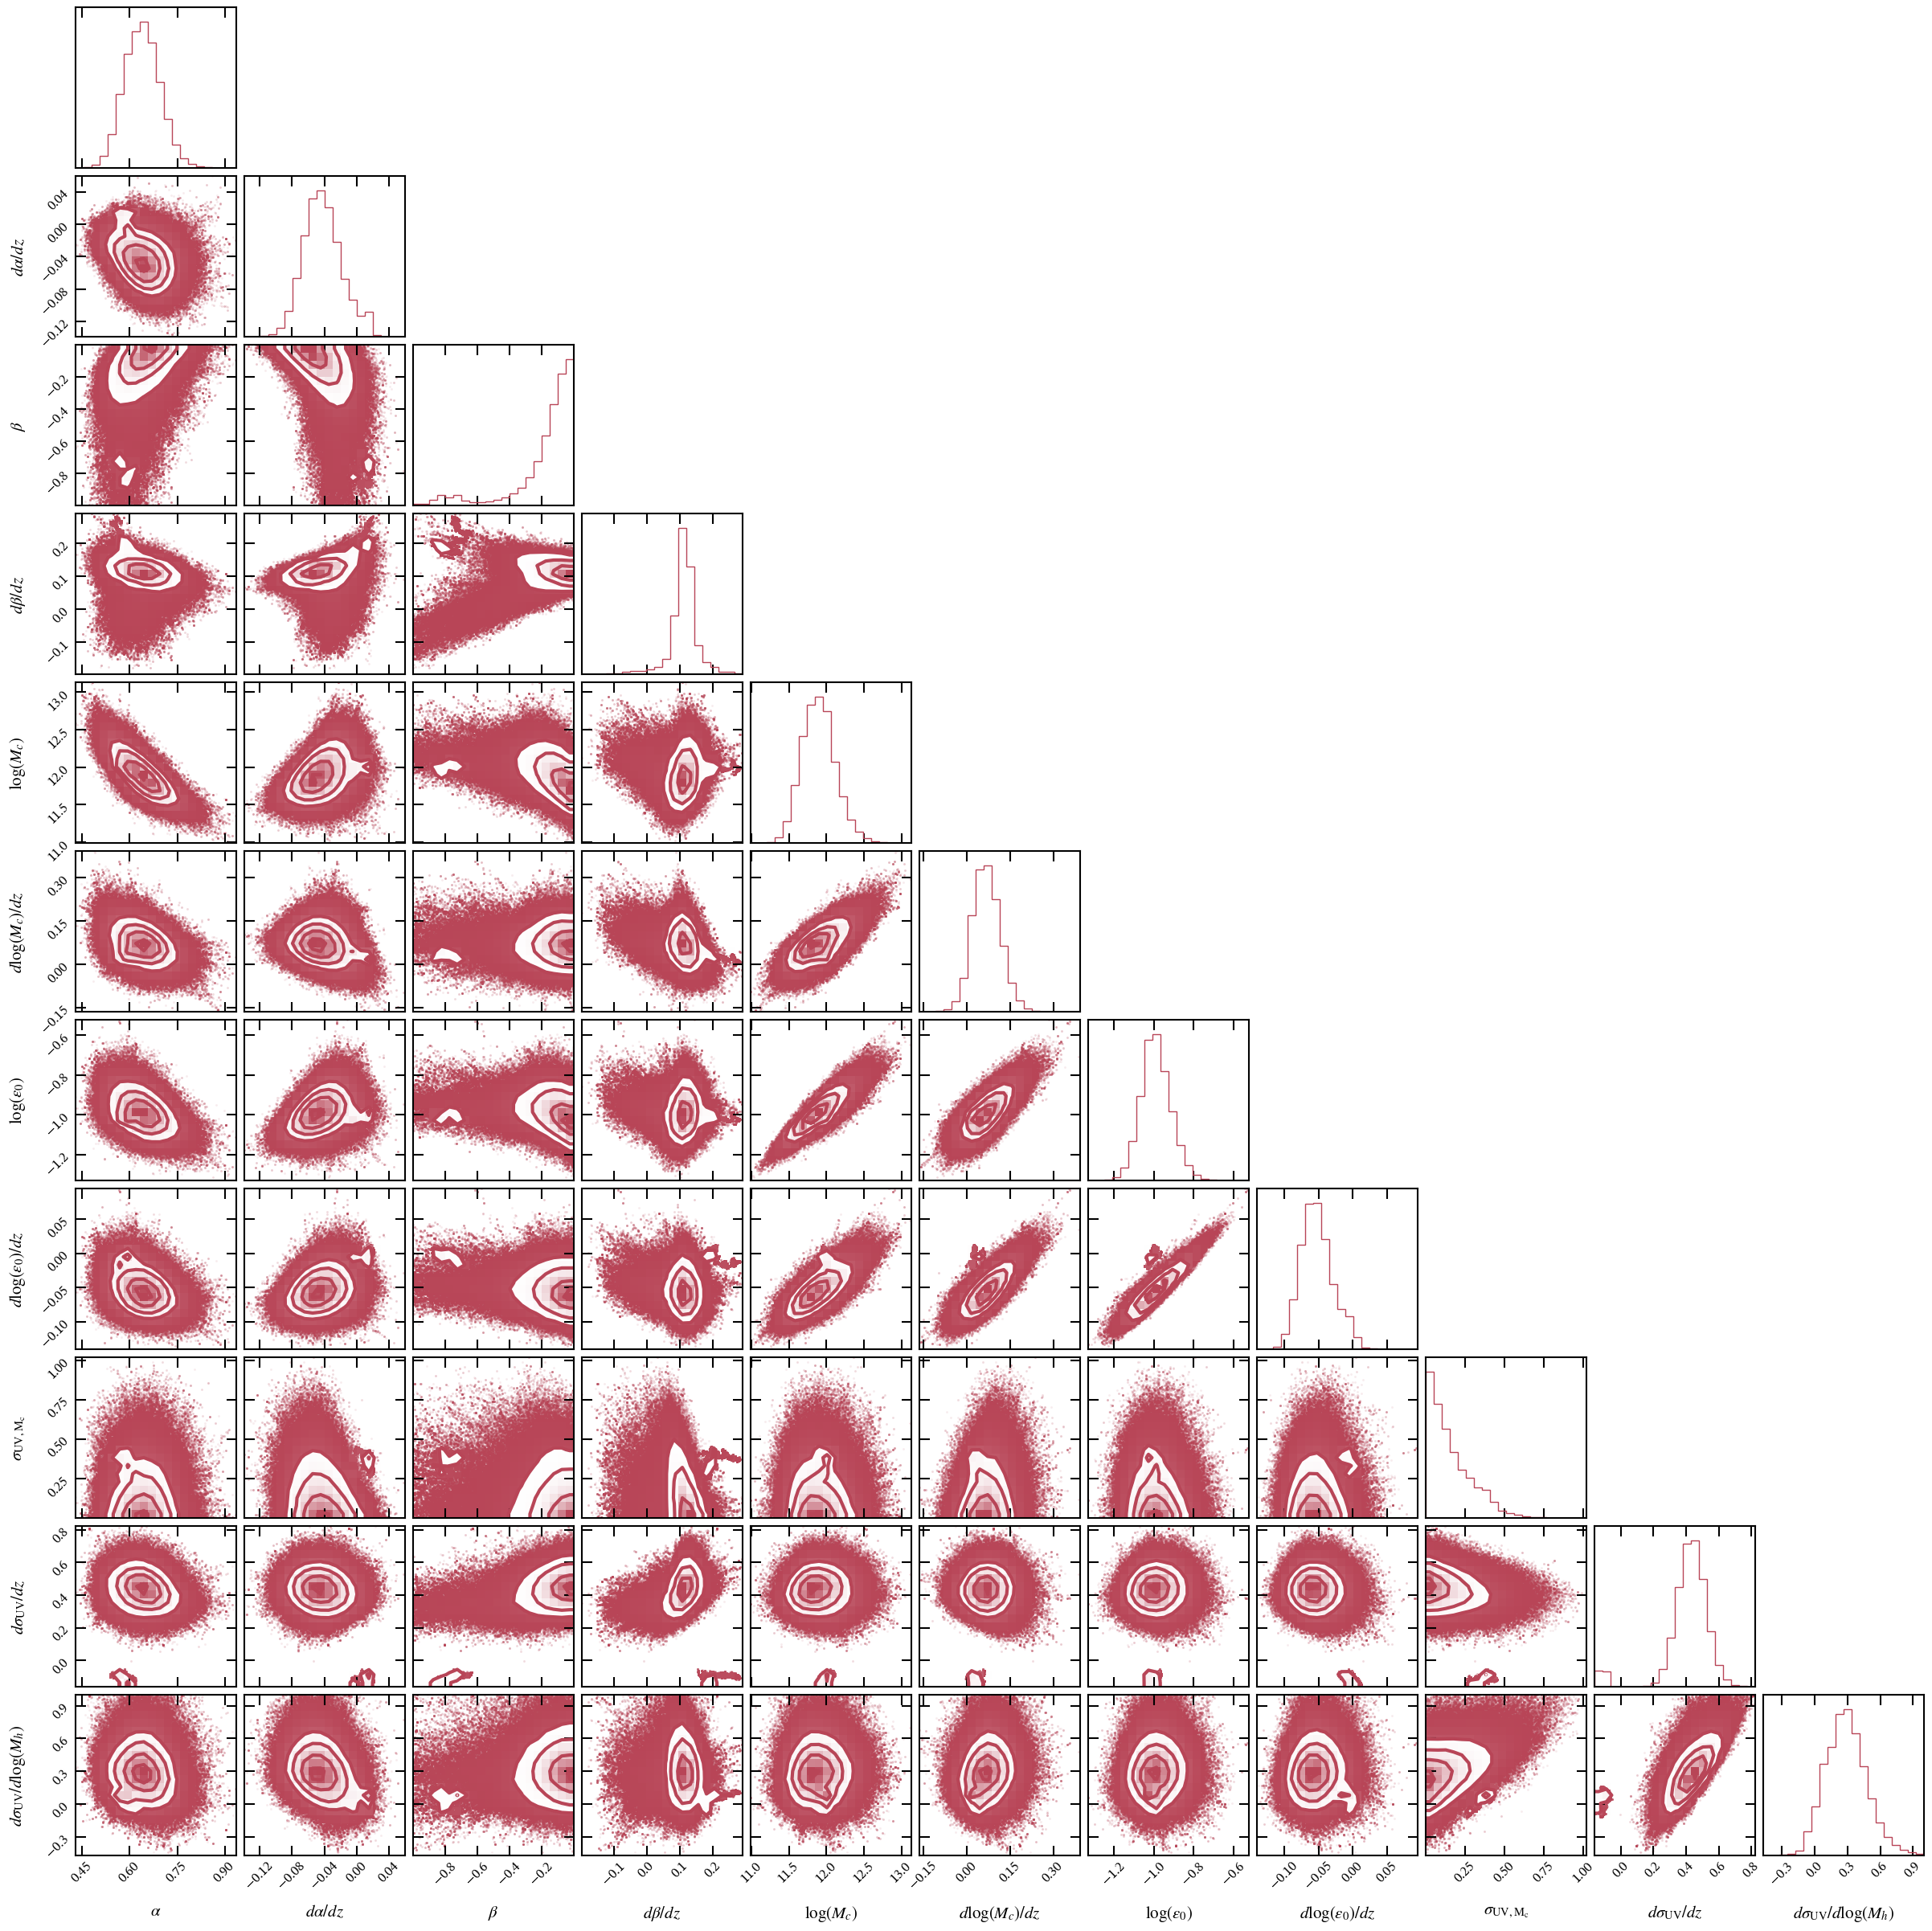

In [19]:
corner = eplots.make_corner(my_UVLF)

In [22]:
corner.savefig('/Users/eb35267/Desktop/code/figures/corner_narrow_ICs.png', bbox_inches = 'tight')

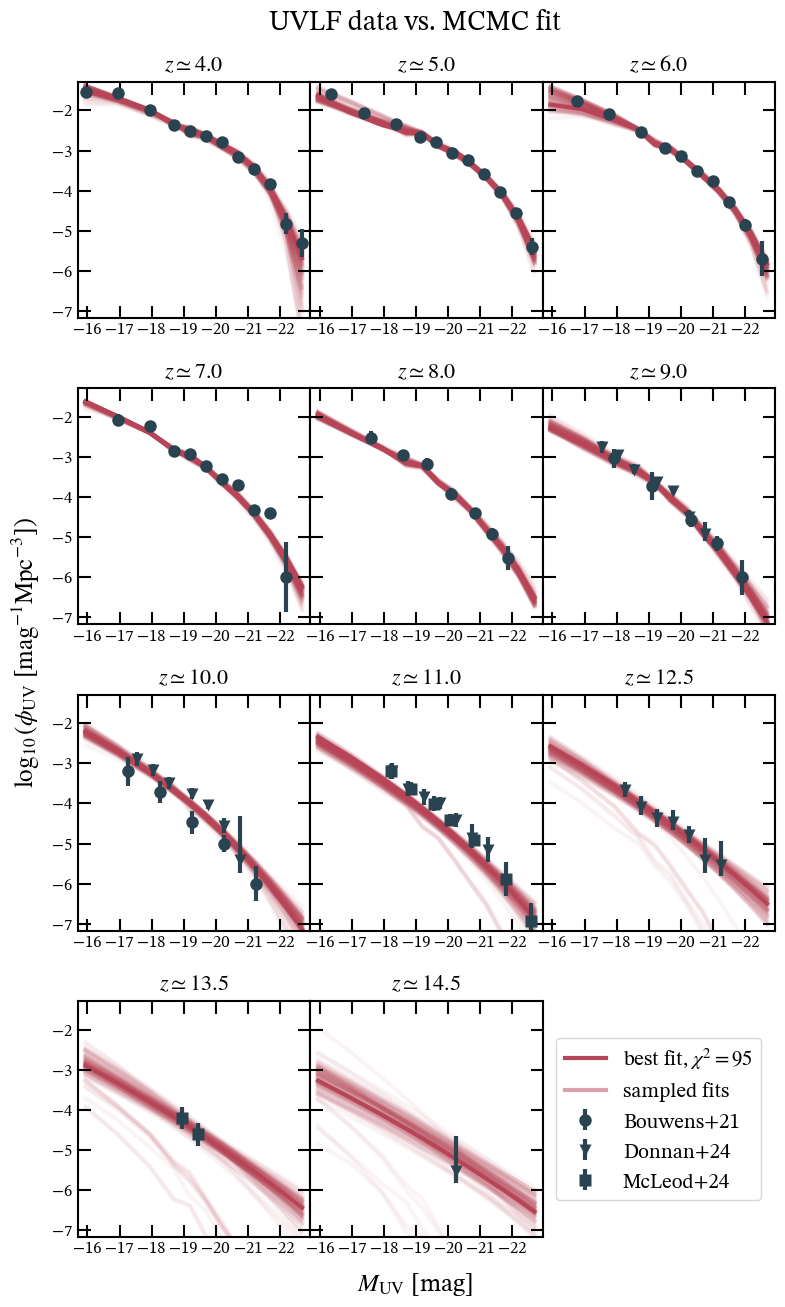

In [20]:
ev_fig = eplots.evolving_UVLF_fit(my_UVLF, ncols = 3)